# Ptychography Reconstruction

This notebook demonstrates a simulated ptychographic reconstruction using tike.

In [1]:
import logging

import matplotlib.pyplot as plt
import numpy as np

import tike
import tike.ptycho
import tike.view

In [2]:
for module in [tike, np]:
    print("{} is version {}".format(module.__name__, module.__version__))

tike is version 0.10.1.dev78+g205bf46.d20201029
numpy is version 1.19.4


## Load test data
This data was simulated using tike and it used for continuous integration testing.

In [3]:
import lzma
import pickle

with lzma.open('../../../tests/data/ptycho_setup.pickle.lzma', 'rb') as file:
    [
        data,
        scan,
        probe,
        original,
    ] = pickle.load(file)

### Define the object
The object consists of two unique views of varying phase: one with constant amplitude and one with varying amplitude.

In [4]:
original.shape

(2, 128, 128)

(-0.9999991+0.001338858j) (0.9940698+0.108743966j)


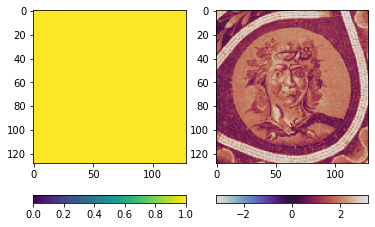

(-0.9617499+0.057536483j) (0.9270641+0.10761326j)


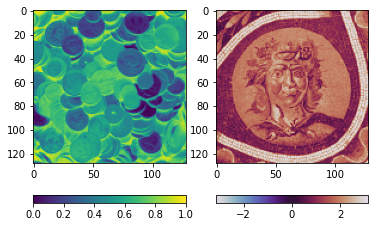

In [5]:
for i in range(len(original)):
    plt.figure()
    tike.view.plot_phase(original[i], amax=1, amin=0)
    plt.show()

### Define the probe

Note that the shape of the probe includes many dimensions. These dimensions are for providing multiple incoherent probes and coherent probbes along with unique probes for multiple dimensions. Read the documentation of the `tike.ptycho.probe` module for more information.

In [6]:
probe.shape

(2, 1, 1, 2, 16, 16)

/home/dching/Documents/tike/src/tike/view.py:94: UserWarning: This phase plot will be incorrect because the phase of a zero-amplitude complex number is undefined. Adding a small constant to the amplitude may help.
  warnings.warn(


(-0.62939256+0.7770875j) (0.99999994+0.00031415926j)


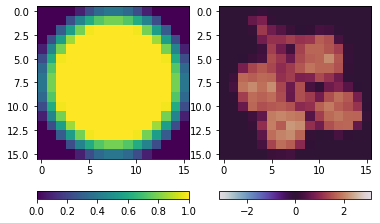

(-0.49423975+0.0756775j) (0.49854407+0.03812901j)


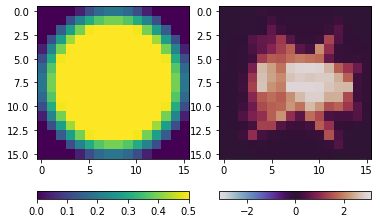

In [7]:
for m in range(probe.shape[-3]):
    plt.figure()
    tike.view.plot_phase(probe[0, 0, 0, m])
    plt.show()

Information about a probe which varies with each scanning position is stored in the `weights` and `coherent_probe` arrays.

In [8]:
# Add some probe variance
np.random.seed(0)
true_coherent_probe = probe
weights = tike.ptycho.probe.simulate_variable_weights(scan, true_coherent_probe)
true_probe = tike.ptycho.probe.get_unique(probe, coherent_probe=true_coherent_probe, weights=weights)

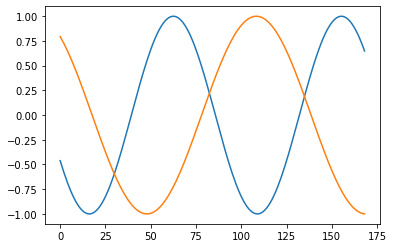

In [9]:
plt.figure()
plt.plot(weights[0, :, 0, 0])
plt.plot(weights[0, :, 0, 1])

### Define the trajectory

Each view may have a different trajectory, but the number of scan positions must be the same. The probe positions that overlap the edge of psi are not allowed.

In [10]:
scan.shape

(2, 169, 2)

In [11]:
# Add some position noise
np.random.seed(0)
true_scan = scan + 1 * (2 * np.random.rand(*scan.shape) - 1)

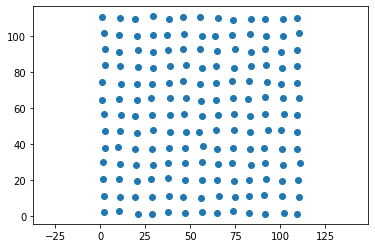

In [12]:
plt.figure()
plt.scatter(true_scan[0, :, 0], true_scan[0, :, 1])
plt.axis('equal')
plt.show()

## Simulate data acquisition

In [13]:
# Then what we see at the detector is the wave propagation
# of the near field wavefront
data = tike.ptycho.simulate(detector_shape=probe.shape[-1] * 2,
                            probe=true_probe, scan=true_scan,
                            psi=original)
data.shape

(2, 169, 32, 32)

In [14]:
# np.random.seed(0)
# data = np.random.poisson(data)

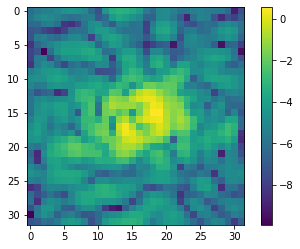

(9.584223e-08, 61.403507)

In [15]:
plt.figure()
plt.imshow(np.fft.fftshift(np.log(data[0, 11])))
plt.colorbar()
plt.show()
np.min(data), np.max(data)

## Reconstruct

Now we need to try and reconstruct psi.

In [16]:
coherent_probe, weights = tike.ptycho.probe.init_variable_probe(scan, probe, 1)

In [17]:
coherent_probe.shape, weights.shape

((2, 1, 1, 2, 16, 16), (2, 169, 1, 2))

In [18]:
# Provide initial guesses for parameters that are updated
result = {
    'psi': np.ones(original.shape, dtype='complex64'),
    'probe': probe,
    'scan': scan,
    'coherent_probe': coherent_probe,
    'weights': weights,
}

In [19]:
logging.basicConfig(level=logging.INFO)

result = tike.ptycho.reconstruct(
    data=data,
    **result,
    algorithm='lstsq_grad',
    num_iter=512,
    recover_probe=True,
)

INFO:tike.ptycho.ptycho:lstsq_grad for 169 - 32 by 32 frames for 512 iterations.
INFO:tike.ptycho.ptycho:object and probe rescaled by 0.952622
INFO:tike.ptycho.ptycho:lstsq_grad epoch 0
INFO:tike.ptycho.solvers.divided:  farplane cost is +2.04263e+04
INFO:tike.ptycho.solvers.divided:  farplane cost is +5.10658e+03
INFO:tike.ptycho.solvers.divided: nearplane cost is +6.38198e+01
INFO:tike.ptycho.solvers.divided:Updating coherent probes
INFO:tike.ptycho.solvers.divided: nearplane cost is +2.80290e+01
INFO:tike.ptycho.solvers.divided: nearplane cost is +3.21498e+01
INFO:tike.ptycho.solvers.divided:Updating coherent probes
INFO:tike.ptycho.solvers.divided: nearplane cost is +1.91163e+01
INFO:tike.ptycho.ptycho:lstsq_grad epoch 1
INFO:tike.ptycho.solvers.divided:  farplane cost is +8.51442e+03
INFO:tike.ptycho.solvers.divided:  farplane cost is +2.12860e+03
INFO:tike.ptycho.solvers.divided: nearplane cost is +4.18624e+01
INFO:tike.ptycho.solvers.divided:Updating coherent probes
INFO:tike.pt

INFO:tike.ptycho.solvers.divided: nearplane cost is +9.07959e+00
INFO:tike.ptycho.solvers.divided:Updating coherent probes
INFO:tike.ptycho.solvers.divided: nearplane cost is +8.24343e+00
INFO:tike.ptycho.ptycho:lstsq_grad epoch 15
INFO:tike.ptycho.solvers.divided:  farplane cost is +1.06125e+03
INFO:tike.ptycho.solvers.divided:  farplane cost is +2.65313e+02
INFO:tike.ptycho.solvers.divided: nearplane cost is +1.36838e+01
INFO:tike.ptycho.solvers.divided:Updating coherent probes
INFO:tike.ptycho.solvers.divided: nearplane cost is +1.26091e+01
INFO:tike.ptycho.solvers.divided: nearplane cost is +8.83552e+00
INFO:tike.ptycho.solvers.divided:Updating coherent probes
INFO:tike.ptycho.solvers.divided: nearplane cost is +8.03667e+00
INFO:tike.ptycho.ptycho:lstsq_grad epoch 16
INFO:tike.ptycho.solvers.divided:  farplane cost is +1.00719e+03
INFO:tike.ptycho.solvers.divided:  farplane cost is +2.51798e+02
INFO:tike.ptycho.solvers.divided: nearplane cost is +1.33272e+01
INFO:tike.ptycho.solver

INFO:tike.ptycho.solvers.divided: nearplane cost is +6.74596e+00
INFO:tike.ptycho.solvers.divided:Updating coherent probes
INFO:tike.ptycho.solvers.divided: nearplane cost is +6.23241e+00
INFO:tike.ptycho.ptycho:lstsq_grad epoch 30
INFO:tike.ptycho.solvers.divided:  farplane cost is +6.22516e+02
INFO:tike.ptycho.solvers.divided:  farplane cost is +1.55629e+02
INFO:tike.ptycho.solvers.divided: nearplane cost is +1.05538e+01
INFO:tike.ptycho.solvers.divided:Updating coherent probes
INFO:tike.ptycho.solvers.divided: nearplane cost is +1.00511e+01
INFO:tike.ptycho.solvers.divided: nearplane cost is +6.65174e+00
INFO:tike.ptycho.solvers.divided:Updating coherent probes
INFO:tike.ptycho.solvers.divided: nearplane cost is +6.15016e+00
INFO:tike.ptycho.ptycho:lstsq_grad epoch 31
INFO:tike.ptycho.solvers.divided:  farplane cost is +6.08079e+02
INFO:tike.ptycho.solvers.divided:  farplane cost is +1.52020e+02
INFO:tike.ptycho.solvers.divided: nearplane cost is +1.04384e+01
INFO:tike.ptycho.solver

INFO:tike.ptycho.solvers.divided: nearplane cost is +5.72963e+00
INFO:tike.ptycho.solvers.divided:Updating coherent probes
INFO:tike.ptycho.solvers.divided: nearplane cost is +5.34096e+00
INFO:tike.ptycho.ptycho:lstsq_grad epoch 45
INFO:tike.ptycho.solvers.divided:  farplane cost is +4.77228e+02
INFO:tike.ptycho.solvers.divided:  farplane cost is +1.19307e+02
INFO:tike.ptycho.solvers.divided: nearplane cost is +9.32653e+00
INFO:tike.ptycho.solvers.divided:Updating coherent probes
INFO:tike.ptycho.solvers.divided: nearplane cost is +9.00975e+00
INFO:tike.ptycho.solvers.divided: nearplane cost is +5.68532e+00
INFO:tike.ptycho.solvers.divided:Updating coherent probes
INFO:tike.ptycho.solvers.divided: nearplane cost is +5.30180e+00
INFO:tike.ptycho.ptycho:lstsq_grad epoch 46
INFO:tike.ptycho.solvers.divided:  farplane cost is +4.71108e+02
INFO:tike.ptycho.solvers.divided:  farplane cost is +1.17777e+02
INFO:tike.ptycho.solvers.divided: nearplane cost is +9.27195e+00
INFO:tike.ptycho.solver

INFO:tike.ptycho.solvers.divided: nearplane cost is +8.31573e+00
INFO:tike.ptycho.solvers.divided:Updating coherent probes
INFO:tike.ptycho.solvers.divided: nearplane cost is +6.75686e+00
INFO:tike.ptycho.ptycho:lstsq_grad epoch 60
INFO:tike.ptycho.solvers.divided:  farplane cost is +4.70089e+02
INFO:tike.ptycho.solvers.divided:  farplane cost is +1.17522e+02
INFO:tike.ptycho.solvers.divided: nearplane cost is +9.36223e+00
INFO:tike.ptycho.solvers.divided:Updating coherent probes
INFO:tike.ptycho.solvers.divided: nearplane cost is +8.83435e+00
INFO:tike.ptycho.solvers.divided: nearplane cost is +5.46541e+00
INFO:tike.ptycho.solvers.divided:Updating coherent probes
INFO:tike.ptycho.solvers.divided: nearplane cost is +5.00690e+00
INFO:tike.ptycho.ptycho:lstsq_grad epoch 61
INFO:tike.ptycho.solvers.divided:  farplane cost is +7.13677e+02
INFO:tike.ptycho.solvers.divided:  farplane cost is +1.78419e+02
INFO:tike.ptycho.solvers.divided: nearplane cost is +1.08764e+01
INFO:tike.ptycho.solver

...

INFO:tike.ptycho.solvers.divided:  farplane cost is +3.12834e+02
INFO:tike.ptycho.solvers.divided:  farplane cost is +7.82084e+01
INFO:tike.ptycho.solvers.divided: nearplane cost is +7.90774e+00
INFO:tike.ptycho.solvers.divided:Updating coherent probes
INFO:tike.ptycho.solvers.divided: nearplane cost is +7.77101e+00
INFO:tike.ptycho.solvers.divided: nearplane cost is +3.95929e+00
INFO:tike.ptycho.solvers.divided:Updating coherent probes
INFO:tike.ptycho.solvers.divided: nearplane cost is +3.73029e+00
INFO:tike.ptycho.ptycho:lstsq_grad epoch 448
INFO:tike.ptycho.solvers.divided:  farplane cost is +3.16183e+02
INFO:tike.ptycho.solvers.divided:  farplane cost is +7.90458e+01
INFO:tike.ptycho.solvers.divided: nearplane cost is +7.91558e+00
INFO:tike.ptycho.solvers.divided:Updating coherent probes
INFO:tike.ptycho.solvers.divided: nearplane cost is +7.79285e+00
INFO:tike.ptycho.solvers.divided: nearplane cost is +4.04838e+00
INFO:tike.ptycho.solvers.divided:Updating coherent probes
INFO:tik

INFO:tike.ptycho.ptycho:lstsq_grad epoch 462
INFO:tike.ptycho.solvers.divided:  farplane cost is +3.14163e+02
INFO:tike.ptycho.solvers.divided:  farplane cost is +7.85408e+01
INFO:tike.ptycho.solvers.divided: nearplane cost is +7.95392e+00
INFO:tike.ptycho.solvers.divided:Updating coherent probes
INFO:tike.ptycho.solvers.divided: nearplane cost is +7.77169e+00
INFO:tike.ptycho.solvers.divided: nearplane cost is +3.90844e+00
INFO:tike.ptycho.solvers.divided:Updating coherent probes
INFO:tike.ptycho.solvers.divided: nearplane cost is +3.67647e+00
INFO:tike.ptycho.ptycho:lstsq_grad epoch 463
INFO:tike.ptycho.solvers.divided:  farplane cost is +3.11829e+02
INFO:tike.ptycho.solvers.divided:  farplane cost is +7.79573e+01
INFO:tike.ptycho.solvers.divided: nearplane cost is +7.92288e+00
INFO:tike.ptycho.solvers.divided:Updating coherent probes
INFO:tike.ptycho.solvers.divided: nearplane cost is +7.76996e+00
INFO:tike.ptycho.solvers.divided: nearplane cost is +3.89682e+00
INFO:tike.ptycho.solv

INFO:tike.ptycho.solvers.divided: nearplane cost is +3.76999e+00
INFO:tike.ptycho.ptycho:lstsq_grad epoch 477
INFO:tike.ptycho.solvers.divided:  farplane cost is +3.36372e+02
INFO:tike.ptycho.solvers.divided:  farplane cost is +8.40930e+01
INFO:tike.ptycho.solvers.divided: nearplane cost is +8.18556e+00
INFO:tike.ptycho.solvers.divided:Updating coherent probes
INFO:tike.ptycho.solvers.divided: nearplane cost is +7.97670e+00
INFO:tike.ptycho.solvers.divided: nearplane cost is +4.13396e+00
INFO:tike.ptycho.solvers.divided:Updating coherent probes
INFO:tike.ptycho.solvers.divided: nearplane cost is +3.79285e+00
INFO:tike.ptycho.ptycho:lstsq_grad epoch 478
INFO:tike.ptycho.solvers.divided:  farplane cost is +3.15795e+02
INFO:tike.ptycho.solvers.divided:  farplane cost is +7.89487e+01
INFO:tike.ptycho.solvers.divided: nearplane cost is +7.98369e+00
INFO:tike.ptycho.solvers.divided:Updating coherent probes
INFO:tike.ptycho.solvers.divided: nearplane cost is +7.77681e+00
INFO:tike.ptycho.solv

INFO:tike.ptycho.solvers.divided:Updating coherent probes
INFO:tike.ptycho.solvers.divided: nearplane cost is +3.68208e+00
INFO:tike.ptycho.ptycho:lstsq_grad epoch 492
INFO:tike.ptycho.solvers.divided:  farplane cost is +3.11984e+02
INFO:tike.ptycho.solvers.divided:  farplane cost is +7.79959e+01
INFO:tike.ptycho.solvers.divided: nearplane cost is +7.89277e+00
INFO:tike.ptycho.solvers.divided:Updating coherent probes
INFO:tike.ptycho.solvers.divided: nearplane cost is +7.78651e+00
INFO:tike.ptycho.solvers.divided: nearplane cost is +3.96233e+00
INFO:tike.ptycho.solvers.divided:Updating coherent probes
INFO:tike.ptycho.solvers.divided: nearplane cost is +3.72876e+00
INFO:tike.ptycho.ptycho:lstsq_grad epoch 493
INFO:tike.ptycho.solvers.divided:  farplane cost is +3.66984e+02
INFO:tike.ptycho.solvers.divided:  farplane cost is +9.17459e+01
INFO:tike.ptycho.solvers.divided: nearplane cost is +8.37975e+00
INFO:tike.ptycho.solvers.divided:Updating coherent probes
INFO:tike.ptycho.solvers.div

INFO:tike.ptycho.solvers.divided: nearplane cost is +4.09921e+00
INFO:tike.ptycho.solvers.divided:Updating coherent probes
INFO:tike.ptycho.solvers.divided: nearplane cost is +3.77984e+00
INFO:tike.ptycho.ptycho:lstsq_grad epoch 507
INFO:tike.ptycho.solvers.divided:  farplane cost is +3.09767e+02
INFO:tike.ptycho.solvers.divided:  farplane cost is +7.74418e+01
INFO:tike.ptycho.solvers.divided: nearplane cost is +7.91099e+00
INFO:tike.ptycho.solvers.divided:Updating coherent probes
INFO:tike.ptycho.solvers.divided: nearplane cost is +7.75145e+00
INFO:tike.ptycho.solvers.divided: nearplane cost is +3.85462e+00
INFO:tike.ptycho.solvers.divided:Updating coherent probes
INFO:tike.ptycho.solvers.divided: nearplane cost is +3.63568e+00
INFO:tike.ptycho.ptycho:lstsq_grad epoch 508
INFO:tike.ptycho.solvers.divided:  farplane cost is +3.06188e+02
INFO:tike.ptycho.solvers.divided:  farplane cost is +7.65469e+01
INFO:tike.ptycho.solvers.divided: nearplane cost is +7.86360e+00
INFO:tike.ptycho.solv

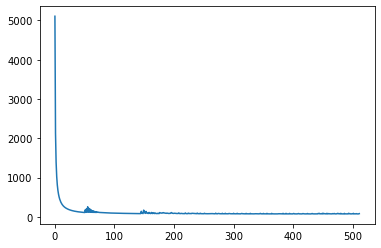

In [20]:
plt.figure()
plt.plot(result['cost'])
plt.show()

(-0.6677764+0.7241797j) (2.5268552+0.4102031j)
(-0.63753134+1.0377729j) (1.2110353+0.023100268j)
(-0.36680368-0.3187487j) (0.32801077-0.80793095j)


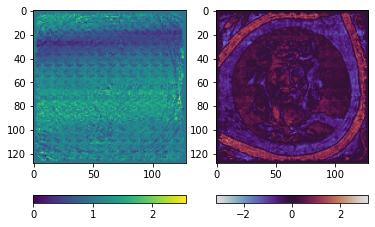

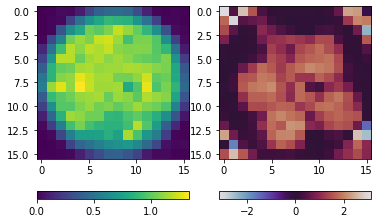

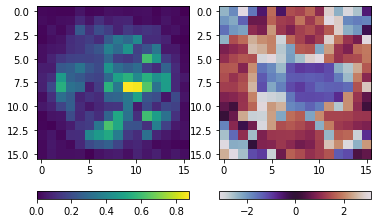

(-0.5507829+0.61471826j) (2.3050377+0.2780926j)
(-0.55641633+0.6056127j) (0.8399498+0.13676472j)
(-0.20139049+0.36021018j) (0.24072875-0.1870266j)


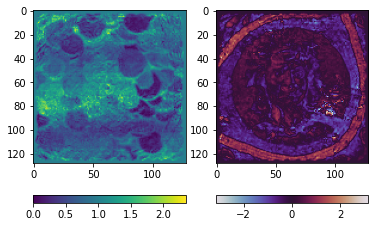

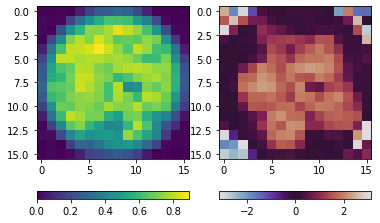

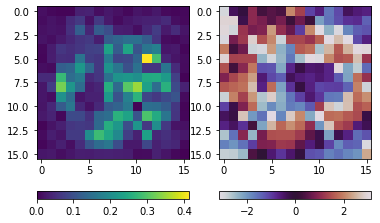

In [21]:
for v in range(len(original)):
    plt.figure()
    tike.view.plot_phase(result['psi'][v], amin=0)
    for m in range(probe.shape[-3]):
        plt.figure()
        tike.view.plot_phase(result['probe'][v, 0, 0, m], amin=0)
    plt.show()